## 前処理03

本ファイルは以下の処理を行うコードである。

1. `/workspace/datasets/statcast-customized/preprocess_02`データセットを読みだす。

2. 試合状況に関するカラムをモデル入力に適した形に成形し、`/workspace/datasets/statcast-customized/preprocess_03`に保存する。

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
load_root_path = '/workspace/datasets/statcast-customized-tmp/preprocess_02/'
save_root_path = '/workspace/datasets/statcast-customized-tmp/preprocess_03/'

In [3]:
def get_parquet_file_path_list(load_root_path):
    file_path_list = []
    # Walk through the directory and its subdirectories to find all Parquet files
    for root, dirs, files in os.walk(load_root_path):
        for file in files:
            if file.endswith('.parquet'):
                file_path_list.append(os.path.join(root, file))
    # Sort the file paths to ensure consistent order
    file_path_list.sort()
    return file_path_list

In [4]:
def load_parquet(path: str) -> pd.DataFrame:
    """Read a Parquet file and return a pandas DataFrame."""
    return pd.read_parquet(path)

In [5]:
parquet_file_path_list = get_parquet_file_path_list(load_root_path)
for file_path in parquet_file_path_list:
    print(f'Load: {file_path}')
print(f'Number of Parquet files: {len(parquet_file_path_list)}')

Load: /workspace/datasets/statcast-customized-tmp/preprocess_02/statcast_2017_04.parquet
Load: /workspace/datasets/statcast-customized-tmp/preprocess_02/statcast_2017_05.parquet
Load: /workspace/datasets/statcast-customized-tmp/preprocess_02/statcast_2017_06.parquet
Load: /workspace/datasets/statcast-customized-tmp/preprocess_02/statcast_2017_07.parquet
Load: /workspace/datasets/statcast-customized-tmp/preprocess_02/statcast_2017_08.parquet
Load: /workspace/datasets/statcast-customized-tmp/preprocess_02/statcast_2017_09.parquet
Load: /workspace/datasets/statcast-customized-tmp/preprocess_02/statcast_2017_10.parquet
Load: /workspace/datasets/statcast-customized-tmp/preprocess_02/statcast_2017_11.parquet
Load: /workspace/datasets/statcast-customized-tmp/preprocess_02/statcast_2018_03.parquet
Load: /workspace/datasets/statcast-customized-tmp/preprocess_02/statcast_2018_04.parquet
Load: /workspace/datasets/statcast-customized-tmp/preprocess_02/statcast_2018_05.parquet
Load: /workspace/data

In [6]:
# データの確認
df_one_month = load_parquet(parquet_file_path_list[0])
with pd.option_context('display.max_columns', None, 'display.max_rows', None):
    display(df_one_month.head(20))

,at_bat_id,description,bb_type,launch_speed,launch_angle,hit_distance_sc,p_throws,pitch_type,release_speed,release_spin_rate,pfx_x,pfx_z,plate_x,plate_z,batter,stand,inning,inning_topbot,outs_when_up,balls,strikes,on_1b,on_2b,on_3b,bat_score,fld_score,pitch_number
0,0,ball,None,NaN,NaN,NaN,R,FF,94.9,2146.0,-0.78,1.10,0.281634,4.334447,656941,L,1,Top,0,0,0,NaN,NaN,NaN,0,0,1
1,0,foul,None,NaN,NaN,NaN,R,SI,95.9,2144.0,-1.59,0.84,-0.578784,2.324124,656941,L,1,Top,0,1,0,NaN,NaN,NaN,0,0,2
2,0,ball,None,NaN,NaN,NaN,R,SI,97.3,2015.0,-1.34,0.55,-0.014284,1.326134,656941,L,1,Top,0,1,1,NaN,NaN,NaN,0,0,3
3,0,hit_into_play,line_drive,96.1,18.0,256.0,R,SL,84.6,2194.0,1.10,-0.17,0.135816,1.943402,656941,L,1,Top,0,2,1,NaN,NaN,NaN,0,0,4
4,1,called_strike,None,NaN,NaN,NaN,R,SI,98.4,2066.0,-1.28,0.68,0.421448,1.833604,592178,R,1,Top,0,0,0,656941.0,NaN,NaN,0,0,1
5,1,ball,None,NaN,NaN,NaN,R,SI,96.3,2086.0,-1.20,0.68,0.624980,2.677019,592178,R,1,Top,0,0,1,656941.0,NaN,NaN,0,0,2
6,1,ball,None,NaN,NaN,NaN,R,SL,86.6,2333.0,1.42,0.65,2.357224,1.320178,592178,R,1,Top,0,1,1,656941.0,NaN,NaN,0,0,3
7,1,called_strike,None,NaN,NaN,NaN,R,SL,86.1,2261.0,1.08,-0.03,0.263640,1.705923,592178,R,1,Top,0,2,1,656941.0,NaN,NaN,0,0,4
8,1,swinging_strike,None,NaN,NaN,NaN,R,FF,99.9,2278.0,-0.85,1.19,-0.540721,3.304990,592178,R,1,Top,0,2,2,656941.0,NaN,NaN,0,0,5
9,2,ball,None,NaN,NaN,NaN,R,FF,99.3,2144.0,-0.92,1.21,-0.226224,3.970468,519203,L,1,Top,1,0,0,656941.0,NaN,NaN,0,0,1


In [7]:
def plot_column_distribution(df: pd.DataFrame, column: str, bins: int = 50) -> None:
    """
    指定したカラムの値の分布をヒストグラムで可視化する。

    Parameters
    ----------
    df : pd.DataFrame
        対象のDataFrame
    column : str
        可視化するカラム名
    bins : int
        ヒストグラムのビン数 (デフォルト: 50)
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    data = df[column].dropna()
    ax.hist(data, bins=bins, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of "{column}"', fontsize=14)
    ax.set_xlabel(column, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='green', linestyle='--', label=f'Median: {data.median():.2f}')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(data.describe())

# # 使用例
# plot_column_distribution(df_one_month, 'release_speed')

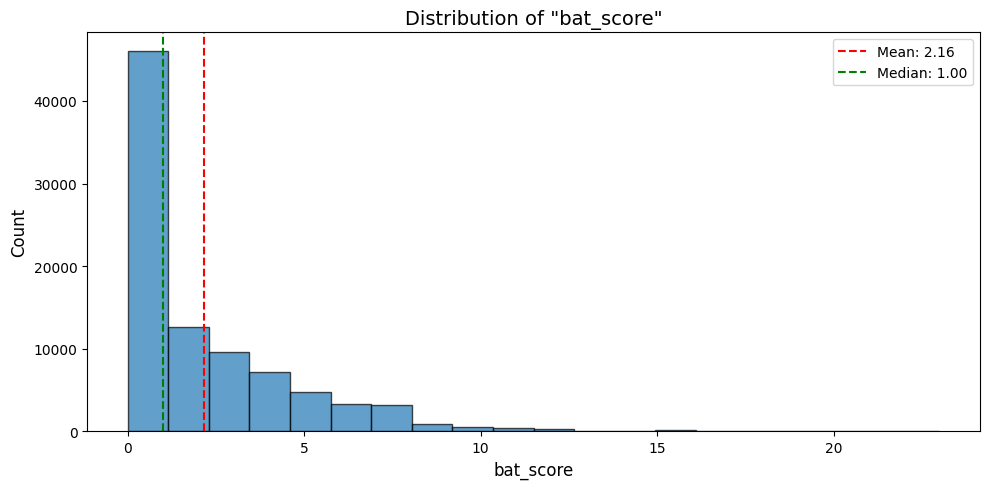

count    89094.000000
mean         2.160785
std          2.490577
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max         23.000000
Name: bat_score, dtype: float64


In [8]:
plot_column_distribution(df_one_month, 'bat_score', 20)

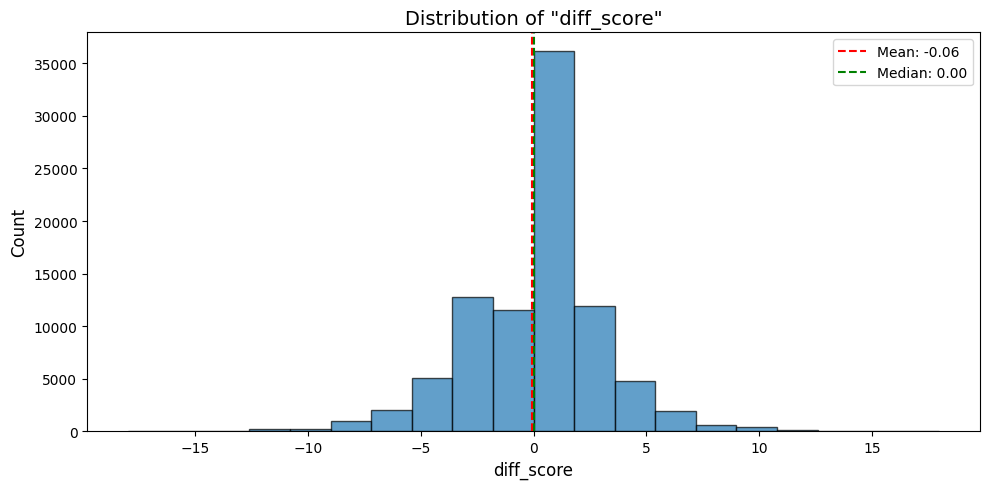

count    89094.000000
mean        -0.055537
std          2.944522
min        -18.000000
25%         -1.000000
50%          0.000000
75%          1.000000
max         18.000000
Name: diff_score, dtype: float64


In [9]:
diff_score = df_one_month['bat_score'] - df_one_month['fld_score']
df_diff_score = pd.DataFrame({'diff_score': diff_score})
plot_column_distribution(df_diff_score, 'diff_score', 20)

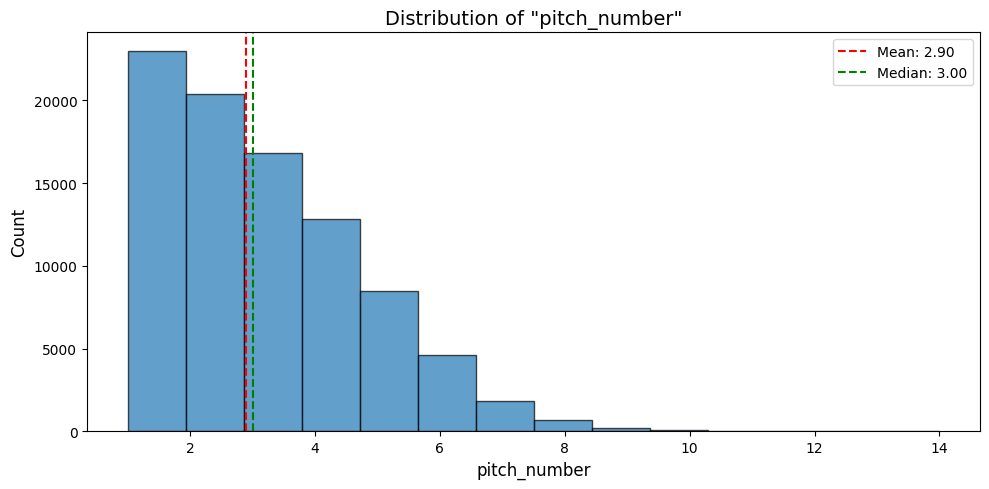

count    89094.000000
mean         2.898276
std          1.723788
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max         14.000000
Name: pitch_number, dtype: float64


In [10]:
plot_column_distribution(df_one_month, 'pitch_number', 14)

## データのOne-Hotベクトル化

野球のセオリー（セイバーメトリクス）に基づき、相互作用が強い変数をグループ化して新しいカテゴリ変数を作成します。

### 1. Base-Out State（24状態）

- 構成: outs_when_up (3通り) × 走者状況 on_1b, 2b, 3b (8通り)

- 理由: 野球の得点期待値（RE24）の算出にも使われる最も標準的な状態定義。「無死一塁」や「二死満塁」など、投手と打者の戦略を決定づける基本単位。24クラスのカテゴリとして扱う。

### 2. Count State（12状態）

- 構成: balls (4通り) × strikes (3通り)

- 理由: 配球（球種やコースの選択）に最も直接的な影響を与える。「0-0」と「3-2」のコンテキストの違いを1つの状態として明示的にモデルに与える。12クラスのカテゴリとして扱う。

### 3. イニングと表裏（独立して扱う）

- inning: クリップする。(1~10イニング)

- inning_topbot: 0/1の1次元バイナリ値としてそのまま入力する。

### 4. その他(独立して扱う)

- bat_score, fld_score: diff_score = bat_score - fld_score を作り、[-10, 10] クリップする。(分布から範囲を決定)

- pitch_number: [0, 10] クリップする。(分布から範囲を決定)

In [11]:
def add_sabermetrics_onehot_features(df: pd.DataFrame, inning_cap: int = 10) -> pd.DataFrame:
    """
    セイバーメトリクスに基づく状態量を作成し、One-Hotベクトル化した列を追加して返す。

    追加される主な列:
      - base_out_state (0-23) + base_out_state_* (24列)
      - count_state (0-11) + count_state_* (12列)
      - inning_clipped + inning_* (1..inning_cap)
      - inning_topbot_bin (Top=1, Bot=0)
    """
    out = df.copy()

    # --- 1) Base-Out State (24 states) ---
    # 走者有無を0/1化（IDが入っているので non-null を在塁とみなす）
    on1 = out["on_1b"].notna().astype("int8")
    on2 = out["on_2b"].notna().astype("int8")
    on3 = out["on_3b"].notna().astype("int8")

    # 走者状態を 0..7 にエンコード (1b + 2*2b + 4*3b)
    base_state = on1 + (on2 * 2) + (on3 * 4)

    # outs は 0..2 にクリップ
    outs = out["outs_when_up"].clip(lower=0, upper=2).astype("int8")

    # 0..23: outs * 8 + base_state
    out["base_out_state"] = (outs * 8 + base_state).astype("int8")

    # --- 2) Count State (12 states) ---
    balls = out["balls"].clip(lower=0, upper=3).astype("int8")
    strikes = out["strikes"].clip(lower=0, upper=2).astype("int8")

    # 0..11: balls * 3 + strikes
    out["count_state"] = (balls * 3 + strikes).astype("int8")

    # --- 3) Inning / Top-Bottom ---
    out["inning_clipped"] = out["inning"].clip(lower=1, upper=inning_cap).astype("int16")
    out["is_inning_top"] = out["inning_topbot"].map({"Top": True, "Bot": False}).astype("bool")

    # --- 4) Score Differential ---
    out["diff_score_clipped"] = (out["bat_score"] - out["fld_score"]).clip(lower=-10, upper=10).astype("int8")

    # --- 5) Pitch Number ---
    out["pitch_number_clipped"] = out["pitch_number"].clip(lower=1, upper=10).astype("int8")

    # 不要な列を削除
    out = out.drop(columns=["on_1b", "on_2b", "on_3b", "outs_when_up", "balls", "strikes", "inning", "inning_topbot"])
    out = out.drop(columns=["bat_score", "fld_score", "pitch_number"])
    return out

In [12]:
# 使用例
df_one_month_with_features = add_sabermetrics_onehot_features(df_one_month)
with pd.option_context('display.max_columns', None, 'display.max_rows', None):
    display(df_one_month_with_features.head(20))

,at_bat_id,description,bb_type,launch_speed,launch_angle,hit_distance_sc,p_throws,pitch_type,release_speed,release_spin_rate,pfx_x,pfx_z,plate_x,plate_z,batter,stand,base_out_state,count_state,inning_clipped,is_inning_top,diff_score_clipped,pitch_number_clipped
0,0,ball,None,NaN,NaN,NaN,R,FF,94.9,2146.0,-0.78,1.10,0.281634,4.334447,656941,L,0,0,1,True,0,1
1,0,foul,None,NaN,NaN,NaN,R,SI,95.9,2144.0,-1.59,0.84,-0.578784,2.324124,656941,L,0,3,1,True,0,2
2,0,ball,None,NaN,NaN,NaN,R,SI,97.3,2015.0,-1.34,0.55,-0.014284,1.326134,656941,L,0,4,1,True,0,3
3,0,hit_into_play,line_drive,96.1,18.0,256.0,R,SL,84.6,2194.0,1.10,-0.17,0.135816,1.943402,656941,L,0,7,1,True,0,4
4,1,called_strike,None,NaN,NaN,NaN,R,SI,98.4,2066.0,-1.28,0.68,0.421448,1.833604,592178,R,1,0,1,True,0,1
5,1,ball,None,NaN,NaN,NaN,R,SI,96.3,2086.0,-1.20,0.68,0.624980,2.677019,592178,R,1,1,1,True,0,2
6,1,ball,None,NaN,NaN,NaN,R,SL,86.6,2333.0,1.42,0.65,2.357224,1.320178,592178,R,1,4,1,True,0,3
7,1,called_strike,None,NaN,NaN,NaN,R,SL,86.1,2261.0,1.08,-0.03,0.263640,1.705923,592178,R,1,7,1,True,0,4
8,1,swinging_strike,None,NaN,NaN,NaN,R,FF,99.9,2278.0,-0.85,1.19,-0.540721,3.304990,592178,R,1,8,1,True,0,5
9,2,ball,None,NaN,NaN,NaN,R,FF,99.3,2144.0,-0.92,1.21,-0.226224,3.970468,519203,L,9,0,1,True,0,1


In [13]:
def decode_sabermetrics_state_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    df内の base_out_state, count_state から以下の列を復元した新しいDataFrameを返す。
      - outs_when_up
      - on_1b
      - on_2b
      - on_3b
      - strikes
      - balls

    ※ on_1b, on_2b, on_3b は走者有無を 0/1 で表す。
    """
    out = df.copy()

    if "base_out_state" not in out.columns:
        raise KeyError("base_out_state 列が存在しません。")
    if "count_state" not in out.columns:
        raise KeyError("count_state 列が存在しません。")

    base_out_state = out["base_out_state"].astype("int16")
    count_state = out["count_state"].astype("int16")

    # base_out_state = outs_when_up * 8 + base_state
    # base_state = on_1b + 2 * on_2b + 4 * on_3b
    out["outs_when_up"] = (base_out_state // 8).astype("int8")
    base_state = (base_out_state % 8).astype("int8")

    out["on_1b"] = (base_state % 2).astype("int8")
    out["on_2b"] = ((base_state // 2) % 2).astype("int8")
    out["on_3b"] = ((base_state // 4) % 2).astype("int8")

    # count_state = balls * 3 + strikes
    out["balls"] = (count_state // 3).astype("int8")
    out["strikes"] = (count_state % 3).astype("int8")

    return out

# 使用例
# df_decoded = decode_sabermetrics_state_features(df_one_month_with_features)
# display(df_decoded.head())

In [14]:
df_decoded = decode_sabermetrics_state_features(df_one_month_with_features)
with pd.option_context('display.max_columns', None, 'display.max_rows', None):
    display(df_decoded.head(20))

,at_bat_id,description,bb_type,launch_speed,launch_angle,hit_distance_sc,p_throws,pitch_type,release_speed,release_spin_rate,pfx_x,pfx_z,plate_x,plate_z,batter,stand,base_out_state,count_state,inning_clipped,is_inning_top,diff_score_clipped,pitch_number_clipped,outs_when_up,on_1b,on_2b,on_3b,balls,strikes
0,0,ball,None,NaN,NaN,NaN,R,FF,94.9,2146.0,-0.78,1.10,0.281634,4.334447,656941,L,0,0,1,True,0,1,0,0,0,0,0,0
1,0,foul,None,NaN,NaN,NaN,R,SI,95.9,2144.0,-1.59,0.84,-0.578784,2.324124,656941,L,0,3,1,True,0,2,0,0,0,0,1,0
2,0,ball,None,NaN,NaN,NaN,R,SI,97.3,2015.0,-1.34,0.55,-0.014284,1.326134,656941,L,0,4,1,True,0,3,0,0,0,0,1,1
3,0,hit_into_play,line_drive,96.1,18.0,256.0,R,SL,84.6,2194.0,1.10,-0.17,0.135816,1.943402,656941,L,0,7,1,True,0,4,0,0,0,0,2,1
4,1,called_strike,None,NaN,NaN,NaN,R,SI,98.4,2066.0,-1.28,0.68,0.421448,1.833604,592178,R,1,0,1,True,0,1,0,1,0,0,0,0
5,1,ball,None,NaN,NaN,NaN,R,SI,96.3,2086.0,-1.20,0.68,0.624980,2.677019,592178,R,1,1,1,True,0,2,0,1,0,0,0,1
6,1,ball,None,NaN,NaN,NaN,R,SL,86.6,2333.0,1.42,0.65,2.357224,1.320178,592178,R,1,4,1,True,0,3,0,1,0,0,1,1
7,1,called_strike,None,NaN,NaN,NaN,R,SL,86.1,2261.0,1.08,-0.03,0.263640,1.705923,592178,R,1,7,1,True,0,4,0,1,0,0,2,1
8,1,swinging_strike,None,NaN,NaN,NaN,R,FF,99.9,2278.0,-0.85,1.19,-0.540721,3.304990,592178,R,1,8,1,True,0,5,0,1,0,0,2,2
9,2,ball,None,NaN,NaN,NaN,R,FF,99.3,2144.0,-0.92,1.21,-0.226224,3.970468,519203,L,9,0,1,True,0,1,1,1,0,0,0,0


In [15]:
def get_features_and_save_parquet(parquet_file_path, save_root_path):
    df = load_parquet(parquet_file_path)
    df_with_features = add_sabermetrics_onehot_features(df)

    # Create the save path by replacing the load root with the save root
    relative_path = os.path.relpath(parquet_file_path, load_root_path)
    save_path = os.path.join(save_root_path, relative_path)

    # Ensure the directory exists
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Save the extracted DataFrame to a new Parquet file
    df_with_features.to_parquet(save_path, index=False)
    print(f'Saved extracted data to: {save_path}')

In [16]:
for parquet_file_path in parquet_file_path_list:
    get_features_and_save_parquet(parquet_file_path, save_root_path)

Saved extracted data to: /workspace/datasets/statcast-customized-tmp/preprocess_03/statcast_2017_04.parquet
Saved extracted data to: /workspace/datasets/statcast-customized-tmp/preprocess_03/statcast_2017_05.parquet
Saved extracted data to: /workspace/datasets/statcast-customized-tmp/preprocess_03/statcast_2017_06.parquet
Saved extracted data to: /workspace/datasets/statcast-customized-tmp/preprocess_03/statcast_2017_07.parquet
Saved extracted data to: /workspace/datasets/statcast-customized-tmp/preprocess_03/statcast_2017_08.parquet
Saved extracted data to: /workspace/datasets/statcast-customized-tmp/preprocess_03/statcast_2017_09.parquet
Saved extracted data to: /workspace/datasets/statcast-customized-tmp/preprocess_03/statcast_2017_10.parquet
Saved extracted data to: /workspace/datasets/statcast-customized-tmp/preprocess_03/statcast_2017_11.parquet
Saved extracted data to: /workspace/datasets/statcast-customized-tmp/preprocess_03/statcast_2018_03.parquet
Saved extracted data to: /wo